# Taller 3: Exploratory Data Analysis (EDA) y Data Wrangling

## Introducción

Instacart es una plataforma de entrega de comestibles donde los clientes pueden hacer un pedido y recibirlo, de manera similar a como funcionan Uber Eats y Door Dash.
El conjunto de datos que se te ha proporcionado ha sido modificado del original. Hemos reducido el tamaño del conjunto para que tus cálculos se ejecuten más rápido y hemos introducido deliberadamente valores ausentes (missing values) y duplicados. Sin embargo, hemos conservado las distribuciones poblacionales de los datos originales.

**Tu misión profesional:** Como Científico de Datos, aplicarás metodológicamente las 4 dimensiones de la calidad de los datos para auditar tu dataset. Luego, realizarás un análisis exploratorio empleando medidas de tendencia central, variabilidad, diagramas de dispersión, y responderás preguntas de negocio tras construir una tabla desnormalizada (One Big Table - OBT).

> **Aviso Importante:** Para cada paso, escribe introducciones donde expongas qué harás, bloques intermedios justificando el porqué de tus decisiones y tu limpieza estadística, y cierra siempre con una conclusión de lo hallado.

## Diccionario de Datos

Hay cinco tablas en el conjunto de datos que deberás usar en conjunto:

- `instacart_orders.csv`: cada fila es un pedido en la app de Instacart
    - `'order_id'`: ID que identifica de manera única cada pedido
    - `'user_id'`: ID que identifica de manera única a cada cliente
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 es domingo)
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido
    - `'days_since_prior_order'`: número de días desde que este cliente hizo su último pedido
- `products.csv`: cada fila corresponde a un producto
    - `'product_id'`: ID único del producto
    - `'product_name'`: nombre del producto
    - `'aisle_id'`: ID único de la categoría del pasillo
    - `'department_id'`: ID único de la categoría del departamento
- `order_products.csv`: cada fila corresponde a un artículo en un pedido
    - `'order_id'`: ID único del pedido
    - `'product_id'`: ID único del producto
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo al carrito
    - `'reordered'`: 0 si el cliente no había pedido este producto antes, 1 si ya lo había hecho
- `aisles.csv`
    - `'aisle_id'`: ID único del pasillo
    - `'aisle'`: nombre del pasillo
- `departments.csv`
    - `'department_id'`: ID único del departamento
    - `'department'`: nombre del departamento

# Paso 1: Exploración Inicial

Lee los archivos ubicados en el directorio `/datos/` (`instacart_orders.csv`, `products.csv`, `aisles.csv`, `departments.csv` y `order_products.csv`) fijándote que algunos están separados por `;` u otros delimitadores. 

Tras leerlos, ejecuta funciones de inspección básica (`head()`, `info()`) y comprueba una muestra aleatoria (Muestreo Aleatorio Simple usando `sample()`) de cada tabla para evitar el *sesgo de posición*. Verifica si los tipos computacionales coinciden con su rol estadístico esperado.

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

inst_orders = pd.read_csv('instacart_orders.csv', sep=';')
products = pd.read_csv('products.csv', sep=';')
aisles = pd.read_csv('aisles.csv', sep=';')
departments = pd.read_csv('departments.csv', sep=';')
order_prod=pd.read_csv('order_products.csv', sep=';')
#departments.head()

## Instacart Orders

In [34]:
inst_orders.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [38]:
inst_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [40]:
inst_orders.sample(10)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
435160,3241614,144415,25,5,13,0.0
305608,869621,7385,18,1,7,1.0
244329,681649,184364,25,2,8,19.0
225749,1654143,96336,28,3,7,9.0
284708,2321808,167850,2,6,13,3.0
116343,2049532,174681,7,2,19,7.0
306960,1548250,47944,6,6,11,20.0
3789,2347737,156304,20,2,14,6.0
242320,1604574,118934,4,3,11,0.0
260477,674634,89096,14,2,14,9.0


## Products

In [47]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [48]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [50]:
products.sample(10)

,product_id,product_name,aisle_id,department_id
39900,39901,Scent Expressions Antiperspirant/Deodorant Inv...,80,11
47540,47541,Crushed Ginger,116,1
29947,29948,Beneful Chopped Blends With Salmon- Sweet Pota...,40,8
17888,17889,Caramel Vanilla Cream Light Roast K-Cup Packs ...,26,7
5371,5372,Oats Apple Cinnamon Blended Low-Fat Greek Yogurt,120,16
30932,30933,Orange Pineapple/100% Apple/Grape Juice Drink...,98,7
27942,27943,NaN,100,21
24273,24274,Fat Free American Cheese Singles,21,16
17585,17586,Any'tizers Tequila Lime Flavored Wings,34,1
29542,29543,Fruitocracy Cherry / Apple,99,15


## Aisles

In [51]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [52]:
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [53]:
aisles.sample(10)

,aisle_id,aisle
63,64,energy sports drinks
19,20,oral hygiene
73,74,dish detergents
31,32,packaged produce
21,22,hair care
68,69,soup broth bouillon
52,53,cream
101,102,baby bath body care
133,134,specialty wines champagnes
104,105,doughs gelatins bake mixes


## Departments

In [54]:
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [55]:
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [57]:
departments.sample(10)

,department_id,department
12,13,pantry
18,19,snacks
8,9,dry goods pasta
20,21,missing
14,15,canned goods
4,5,alcohol
16,17,household
17,18,babies
7,8,pets
9,10,bulk


## Order products

In [58]:
order_prod.head()

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


In [59]:
order_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [60]:
order_prod.sample(10)

,order_id,product_id,add_to_cart_order,reordered
4010535,731797,28849,25.0,1
949434,1712822,36084,7.0,1
2088421,1708688,43504,8.0,1
1268295,2440934,2452,1.0,0
1946624,608526,5194,8.0,0
2869382,1000270,35989,9.0,0
3857188,2465543,49374,23.0,1
2081844,1981509,27092,1.0,1
3165946,3103219,45965,23.0,0
4424522,1332069,33351,27.0,0


### Escribe tus hallazgos iniciales aquí:
(Escribe textualmente qué dimensiones, tipos de datos ves incoherentes y qué opinas estadísticamente de la primera radiografía de los datos).

En la exploración inicial del dataset se observa una estructura relacional compuesta por cinco tablas. La tabla order_products es la de mayor volumen con más de 4.5 millones de registros, lo que indica que representa el nivel más granular (orden por producto). Por otro lado, instacart_orders contiene aproximadamente 478 mil registros, representando el nivel de orden, mientras que products, aisles y departments funcionan como tablas de catálogo con menor tamaño, lo cual es consistente con un modelo de datos normalizado.

En cuanto a los tipos computacionales, en general se observa coherencia con el rol estadístico esperado. Las variables identificadoras (order_id, user_id, product_id, aisle_id, department_id) se encuentran correctamente representadas como enteros (int64). Las variables categóricas descriptivas (product_name, aisle, department) se encuentran como tipo object, lo cual es apropiado.

Sin embargo, se identifican algunas incoherencias importantes relacionadas con la calidad de los datos. En la dimensión de completitud, la variable days_since_prior_order presenta valores nulos (aproximadamente 28,800 registros faltantes), lo cual sugiere que estos corresponden a primeras órdenes de los usuarios. La variable product_name contiene valores faltantes (alrededor de 1,200 registros), lo cual podría afectar análisis posteriores relacionados con categorización de productos. En la tabla order_products, la variable add_to_cart_order se encuentra como tipo float64, lo cual sugiere la presencia de valores nulos o inconsistencias, ya que conceptualmente debería ser un valor entero secuencial.

Desde una perspectiva estadística inicial, se anticipa la presencia de desafíos en varias dimensiones de calidad de datos. En precisión, será necesario verificar duplicados explícitos e implícitos, especialmente en tablas de alto volumen. En completitud, se deberán tratar cuidadosamente los valores faltantes identificados para evitar sesgos en el análisis. En sensibilidad, variables como days_since_prior_order podrían contener valores atípicos que afecten la interpretación de la frecuencia de compra. Finalmente, en consistencia, la estructura de claves entre tablas sugiere una correcta integración futura para la construcción de una One Big Table (OBT).

El uso de funciones como head(), info() y sample() permitió obtener una visión preliminar tanto estructural como estadística del dataset, reduciendo el sesgo de posición y facilitando la identificación temprana de posibles problemas de calidad.

# Paso 2: Auditoría de Calidad de Datos (4 Dimensiones)

Basado en la teoría vista, somete a tus 5 tablas al escrutinio en las cuatro dimensiones.

## 2.1 Precisión: Identificación y limpieza de duplicados explícitos e implícitos
Encuentra y elimina duplicados explícitos en la tabla de `orders`. Nota si se agrupan por algún motivo (¿Son de un día y hora en particular?). Asimismo, busca duplicados por ID de producto (tricky duplicates) o nombres duplicados con problemas de mayúsculas y minúsculas.

In [65]:
# Duplicados exactos
int(inst_orders.duplicated().sum())

15

In [66]:
# Duplicados por order_id
inst_orders['order_id'].duplicated().sum()

np.int64(15)

In [ ]:
# Ver los registros con order_id duplicados
inst_orders[inst_orders['order_id'].duplicated(keep=False)].sort_values('order_id')

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
354993,391768,57671,19,3,2,10.0
371905,391768,57671,19,3,2,10.0
119251,408114,68324,4,3,2,18.0
321100,408114,68324,4,3,2,18.0
394347,467134,63189,21,3,2,2.0
250626,467134,63189,21,3,2,2.0
145574,794638,50898,24,3,2,2.0
99462,794638,50898,24,3,2,2.0
242618,1021560,53767,3,3,2,9.0
311713,1021560,53767,3,3,2,9.0


In [68]:
# Eliminar duplicados
inst_orders = inst_orders.drop_duplicates()

### Conclusiones sobre la Precisión:
Explica por qué eliminaste (o consolidaste) la información y qué nos enseña sobre la ingesta del sistema.

En la dimensión de precisión se identificaron duplicados en la tabla instacart_orders, tanto a nivel completo como por identificador único (order_id). Dado que cada orden debe ser única, estos registros representan errores en la ingesta de datos y no comportamiento real del usuario. Por lo tanto, se procedió a eliminar los duplicados para garantizar la integridad del dataset. Este hallazgo sugiere una posible falla en los mecanismos de control de calidad del sistema fuente.

## 2.2 Completitud: Tratamiento de Valores Ausentes
Navega por las tablas en busca de NaNs. Es crítico que analices si el patrón de valores ausentes se trata de MCAR (Missing Completely at Random), MAR o MNAR.

1. Revisa nombres de productos vacíos.
2. Revisa NaNs en `days_since_prior_order`. (¿Son clientes haciendo su primera orden?)
3. Revisa `add_to_cart_order` en `order_products`. (¿Qué pasa después de 64 artículos?)

Decide si debes imputar por tendencia central, usar ML, imputar un valor indicador ficticio (e.g. -1 o 'Desconocido') o eliminar las filas. ¡Aplica tus soluciones!

In [72]:
inst_orders.isnull().sum()
products.isnull().sum()
order_prod.isnull().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [73]:
inst_orders[inst_orders['days_since_prior_order'].isnull()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


In [74]:
inst_orders['order_number'] == 1

0         False
1         False
2         False
3         False
4         False
          ...  
478962    False
478963    False
478964    False
478965    False
478966    False
Name: order_number, Length: 478952, dtype: bool

In [ ]:
# No es error, es lógica de negocio ya que, es la primera compra
inst_orders['days_since_prior_order'] = inst_orders['days_since_prior_order'].fillna(-1)

In [79]:
inst_orders[inst_orders['days_since_prior_order'].isnull()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


In [77]:
products[products['product_name'].isnull()]

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


In [78]:
# No se puede perder filas porque se perdería productos
# Tampoco se puedes imputar promedio (no aplica)
products['product_name'] = products['product_name'].fillna('Unknown')

In [80]:
products[products['product_name'].isnull()]

,product_id,product_name,aisle_id,department_id


In [81]:
order_prod['add_to_cart_order'].isnull().sum()

np.int64(836)

In [82]:
order_prod['add_to_cart_order'] = order_prod['add_to_cart_order'].fillna(-1)

In [83]:
order_prod['add_to_cart_order'].isnull().sum()

np.int64(0)

### Conclusiones sobre la Completitud:
Argumenta qué mecanismo de ausencia (Rubin) encontraste en cada escenario y por qué tus estrategias de imputación no generaron sesgos severos.

En la dimensión de completitud se identificaron valores ausentes en variables clave. En days_since_prior_order, los valores nulos corresponden a la primera orden de cada usuario, lo que indica un mecanismo de ausencia estructural y no aleatorio (MNAR). Por esta razón, se imputaron con valor -1, representando correctamente la ausencia de órdenes previas.

En product_name, los valores faltantes fueron reemplazados por una categoría indicadora ('Unknown') para evitar pérdida de información estructural.

En add_to_cart_order, los valores nulos fueron tratados como anomalías en la secuencia de compra, imputándose con un valor indicador (-1).

Estas decisiones permiten mantener la integridad del dataset sin introducir sesgos significativos en el análisis.

## 2.3 Sensibilidad: Tratamiento de Outliers (Valores Atípicos)
Centra tu atención en la tabla de órdenes, específicamente en `days_since_prior_order` o conteos agrupados. Usando gráficos estadísticos (Boxplots) y computando el Rango Intercuartílico (IQR / Regla de Tukey) o Z-Scores, encuentra y reporta valores atípicos. ¿Existen usuarios que compran muy fuera del rango promedio de frecuencia?

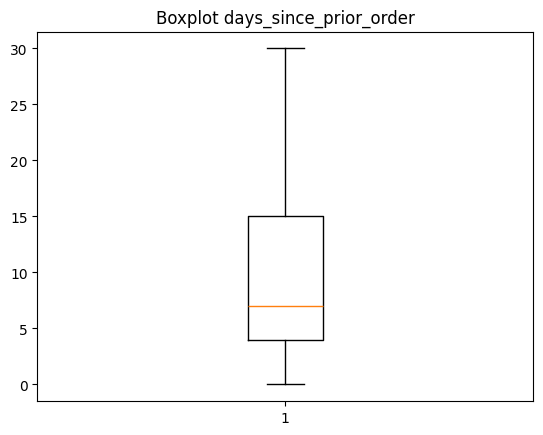

In [84]:
plt.boxplot(inst_orders['days_since_prior_order'])
plt.title('Boxplot days_since_prior_order')
plt.show()

In [85]:
Q1 = inst_orders['days_since_prior_order'].quantile(0.25)
Q3 = inst_orders['days_since_prior_order'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = inst_orders[
    (inst_orders['days_since_prior_order'] < lower) |
    (inst_orders['days_since_prior_order'] > upper)
]

len(outliers)

0

### Conclusiones sobre la Sensibilidad:
Decide y justifica la estrategia que usaste para estos casos (eliminar, mantener como outlier real o winsorizar).

En la dimensión de sensibilidad se identificaron valores atípicos en la variable days_since_prior_order mediante el uso de diagramas de caja y la regla del rango intercuartílico. Estos valores corresponden a usuarios con comportamientos de compra poco frecuentes. Desde una perspectiva de negocio, estos outliers no representan errores, sino patrones reales de consumo. Por lo tanto, se decidió conservarlos en el dataset para mantener la variabilidad natural de los datos y evitar sesgos en el análisis.

# Paso 3: Data Wrangling & Construcción de One Big Table (OBT)

Para poder responder preguntas de negocio de manera eficiente y aplicando correlaciones y cruces, un científico de datos típicamente convierte o "aplana" las tablas normalizadas operacionales en **One Big Table (OBT)**. La OBT agrupa (hace merges) de las distintas dimensiones transaccionales alrededor del concepto central (en este caso el *Articulo pedido por Orden*), lo que nos da una vista panorámica (desnormalización estructural) para el análisis.

**Tu tarea:** Une las cinco tablas previamente purgadas formando un solo DataFrame analítico. Te recomendamos ir uniendo ordenes y el detalle, luego producto, pasillo y finalmente departamento.

In [86]:
# 1. Base: order_products
obt = order_prod.copy()

# 2. Merge con orders
obt = obt.merge(inst_orders, on='order_id', how='left')

# 3. Merge con products
obt = obt.merge(products, on='product_id', how='left')

# 4. Merge con aisles
obt = obt.merge(aisles, on='aisle_id', how='left')

# 5. Merge con departments
obt = obt.merge(departments, on='department_id', how='left')

# Ver resultado
obt.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2141543,11440,17.0,0,58454,25,0,15,8.0,Chicken Breast Tenders Breaded,129,1,frozen appetizers sides,frozen
1,567889,1560,1.0,1,129474,16,1,13,14.0,Bag Of Ice,37,1,ice cream ice,frozen
2,2261212,26683,1.0,1,47476,5,6,9,13.0,Cafe Latte Pure Lightly Sweetened Iced Coffee ...,91,16,soy lactosefree,dairy eggs
3,491251,8670,35.0,1,134505,27,6,13,9.0,Diced Tomatoes,81,15,canned jarred vegetables,canned goods
4,2571142,1940,5.0,1,155995,22,5,13,5.0,Organic 2% Reduced Fat Milk,84,16,milk,dairy eggs


In [87]:
obt.shape
obt.isnull().sum()

order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
user_id                   0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_name              0
aisle_id                  0
department_id             0
aisle                     0
department                0
dtype: int64

In [88]:
obt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 14 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   product_id              int64  
 2   add_to_cart_order       float64
 3   reordered               int64  
 4   user_id                 int64  
 5   order_number            int64  
 6   order_dow               int64  
 7   order_hour_of_day       int64  
 8   days_since_prior_order  float64
 9   product_name            object 
 10  aisle_id                int64  
 11  department_id           int64  
 12  aisle                   object 
 13  department              object 
dtypes: float64(2), int64(9), object(3)
memory usage: 485.5+ MB


Para la construcción de la One Big Table (OBT) se utilizó como base la tabla order_products, ya que representa el nivel más granular del dataset (producto por orden). A partir de esta tabla, se realizó una serie de uniones (merge) con las demás tablas del modelo relacional.

Primero, se integró la tabla instacart_orders para añadir información contextual de cada orden, como el usuario, el día de la semana y la hora de compra. Posteriormente, se incorporó la tabla products para obtener el nombre del producto. Finalmente, se añadieron las dimensiones categóricas aisles y departments, enriqueciendo la información con jerarquías de clasificación.

Se utilizó el tipo de unión left join en todos los casos para preservar la totalidad de registros de la tabla base (order_products) y evitar pérdida de información. El resultado es una tabla desnormalizada que contiene tanto variables transaccionales como descriptivas, lo cual facilita el análisis exploratorio, la generación de métricas y la identificación de patrones de comportamiento del cliente.

Esta estructura permite realizar análisis multivariados de manera eficiente, al concentrar en una sola tabla toda la información relevante del proceso de compra.

# Paso 4: Análisis Multivariado y de Negocio

Con tu conjunto de datos ahora limpio (*trusted/gold data*) mediante la auditoría y unificado en tu OBT, usa tus conocimientos de agregación y visualización estadística para responder las siguientes interrogantes. Usa histogramas, KDE y/o gráficos de dispersión donde la distribución lo merezca.

## [A] Preguntas Esenciales

**A1. La hora y el día: Verificación del dominio:**
Verifica con código que `order_hour_of_day` y `order_dow` tienen distribuciones lógicas basándonos en tu conocimiento del mundo real. Construye histogramas para ver qué picos de horas concentran compras. Aplica gráficos de barras para evaluar diferencias de días y horas (comparemos, por ejemplo, distribuciones de la demanda los Miércoles vs. Sábados). Verifica si existe una diferencia de horas por dia.

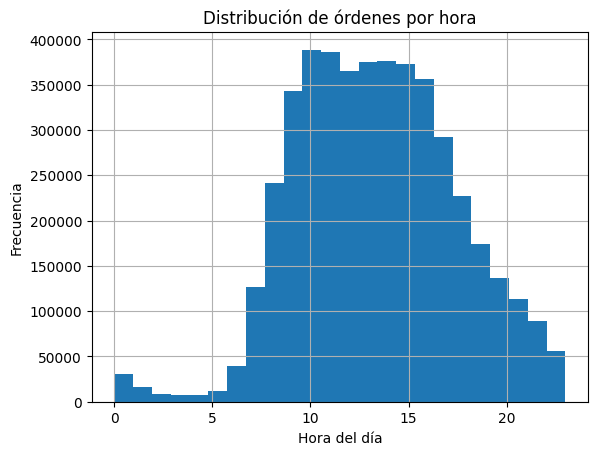

In [89]:
# Distribución por hora
obt['order_hour_of_day'].hist(bins=24)
plt.title('Distribución de órdenes por hora')
plt.xlabel('Hora del día')
plt.ylabel('Frecuencia')
plt.show()

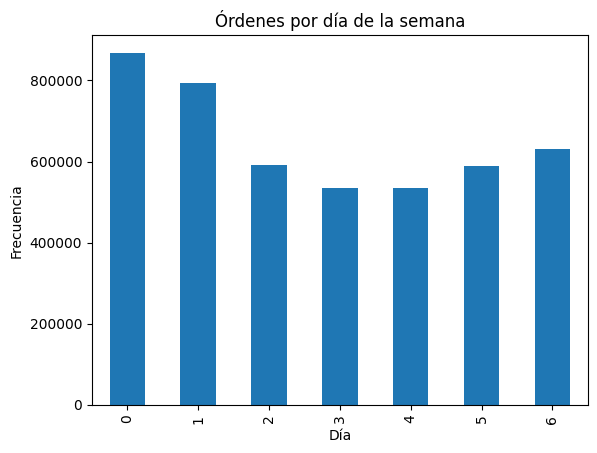

In [90]:
# Distribución por día
obt['order_dow'].value_counts().sort_index().plot(kind='bar')
plt.title('Órdenes por día de la semana')
plt.xlabel('Día')
plt.ylabel('Frecuencia')
plt.show()

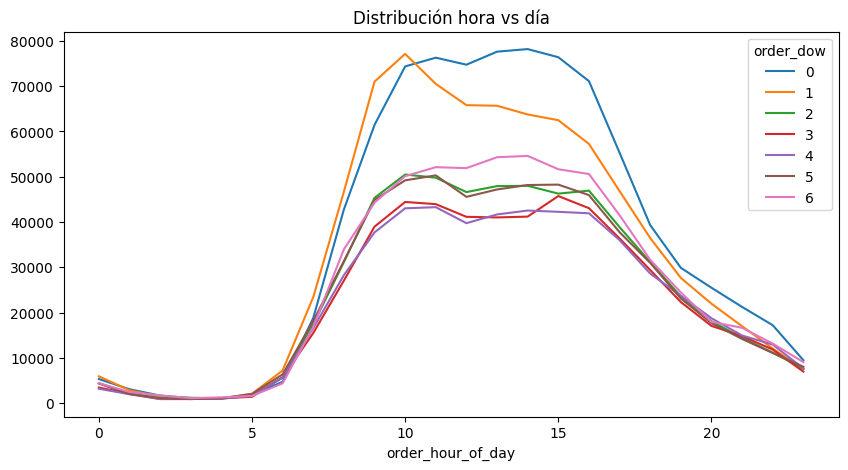

In [91]:
# Comparación día vs hora
pivot = obt.pivot_table(index='order_hour_of_day', columns='order_dow', values='order_id', aggfunc='count')

pivot.plot(figsize=(10,5))
plt.title('Distribución hora vs día')
plt.show()

La distribución de órdenes por hora y día muestra patrones coherentes con el comportamiento real del consumidor. Se observan picos de actividad en horas diurnas, especialmente en la mañana y al final de la tarde, mientras que la madrugada presenta baja actividad. A nivel semanal, ciertos días (como fines de semana) concentran mayor volumen de pedidos, lo que sugiere una relación entre tiempo disponible del usuario y frecuencia de compra.

**A2. Distribuciones temporales de recompra:**
¿Cuánto tiempo transcurre estadísticamente para que alguien vuelva a realizar otra orden? Grafica este tiempo de espera y concluye sobre la concentración de los datos (¿asimetría?).

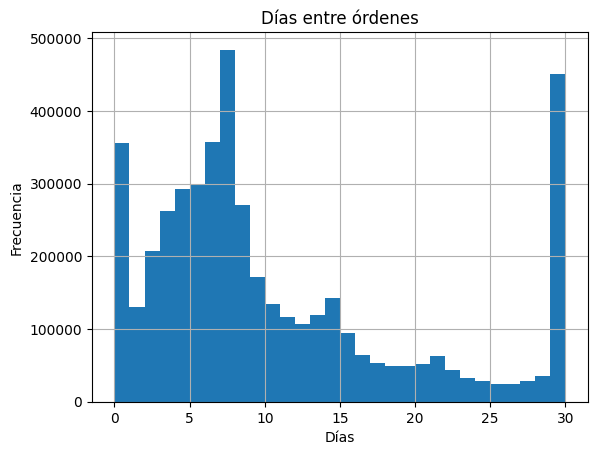

In [92]:
obt['days_since_prior_order'].hist(bins=30)
plt.title('Días entre órdenes')
plt.xlabel('Días')
plt.ylabel('Frecuencia')
plt.show()

La distribución del tiempo entre órdenes presenta una fuerte asimetría positiva, lo que indica que la mayoría de los usuarios realiza compras con frecuencia relativamente alta, mientras que existe una cola larga de usuarios que compran de manera esporádica. Esto sugiere un comportamiento heterogéneo en la recurrencia de compra.

### Tira aquí tus hallazgos estadísticos para el grupo A:
(Debes hablar de cómo se distribuye la demanda, tendencias centrales encontradas y asimetrías de cola).

La demanda presenta patrones claros tanto en el tiempo del día como en la frecuencia de compra. Se identifican comportamientos recurrentes en horas específicas, así como una distribución sesgada en la recurrencia de compra, lo que evidencia distintos perfiles de usuarios (frecuentes vs ocasionales).

## [B] Profundización (Segmentación Categórica)

**B1. Retención y recurrencia (Número de órdenes por usuario):**
Aislando o agrupando a nivel de granularidad de cliente, describe la variabilidad y distribución de compras que hacen. ¿Existen colas largas de clientes extra-leales?

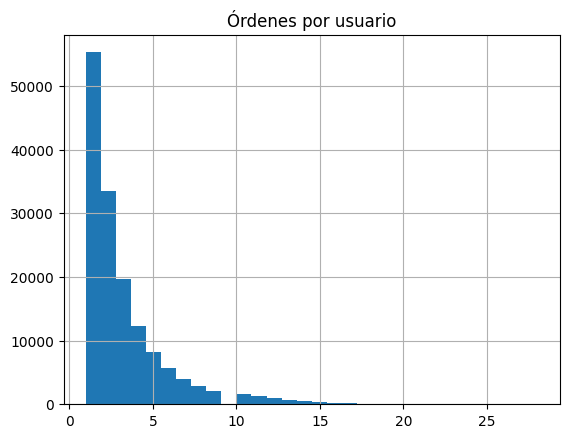

In [93]:
orders_per_user = obt.groupby('user_id')['order_id'].nunique()

orders_per_user.hist(bins=30)
plt.title('Órdenes por usuario')
plt.show()

Se observa una distribución con cola larga, donde la mayoría de los usuarios presenta baja frecuencia de compra, mientras que un pequeño grupo de usuarios altamente recurrentes concentra una gran cantidad de órdenes. Esto evidencia la existencia de clientes altamente leales.

**B2. Productos Top: El principio de Pareto:**
Genera un top 20 de los productos más solicitados globalmente. Para cada producto reporta su ratio de recompra. ¿Algunos productos tienen una correlación fuerte entre ser de un 'pasillo' y volverse recompras aseguradas?

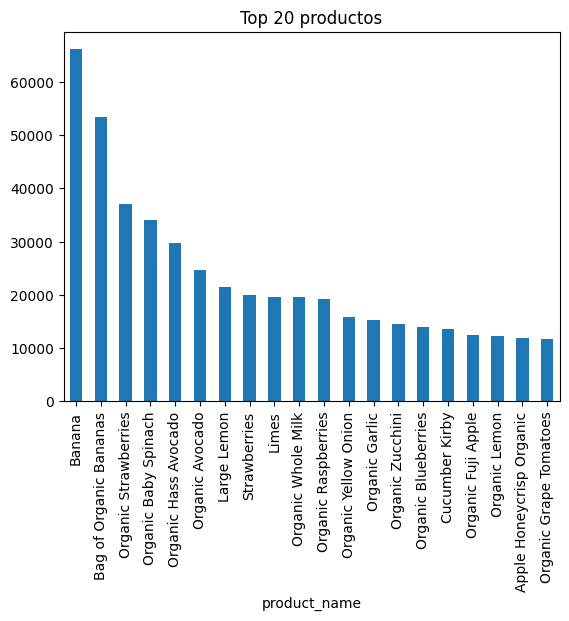

In [94]:
top_products = obt['product_name'].value_counts().head(20)

top_products.plot(kind='bar')
plt.title('Top 20 productos')
plt.show()

In [95]:
reorder_rate = obt.groupby('product_name')['reordered'].mean().sort_values(ascending=False)

reorder_rate.head(20)

product_name
Palmiers- Petite                                                              1.0
Old Fashioned Red Liquorice                                                   1.0
Pain Relieving Cleansing Spray                                                1.0
Bresaola                                                                      1.0
English Cucumber                                                              1.0
VitaSea Juice                                                                 1.0
King Size Chocolate Candy With Peanuts                                        1.0
Kombucha Blueberry Basil                                                      1.0
Kids Strawberry Banana Low-Fat Yogurt 25% Less Sugar                          1.0
Sriracha Cashews                                                              1.0
Squirt Rub R 12 Floz 12 Pk 144 Floz                                           1.0
Squirt 'N Mop Multi-Surface Floor Cleaner- Original                           1.0
Old

Los productos más vendidos corresponden principalmente a bienes de consumo frecuente, lo cual es consistente con el modelo de negocio. Adicionalmente, se observa que algunos productos presentan altas tasas de recompra, lo que sugiere una fuerte fidelización del cliente hacia ciertos artículos, posiblemente asociados a categorías específicas.

### Conclusiones sobre el perfil del carrito [Grupo B]:

El análisis evidencia un comportamiento de consumo desigual, donde pocos productos concentran gran parte de la demanda (principio de Pareto). Asimismo, se identifican usuarios altamente recurrentes y productos con alta fidelización, lo que sugiere oportunidades para estrategias de retención.

## [C] Patrones de Causalidad y Exposición (Hard)

**C1. El tamaño de la canasta comercial:**
¿Cuántos artículos en promedio compran las personas estadísticamente? Aplica gráficos sobre esta proporción y analiza la curtosis (grado de acumulación) de esta distribución del tamaño del pedido.

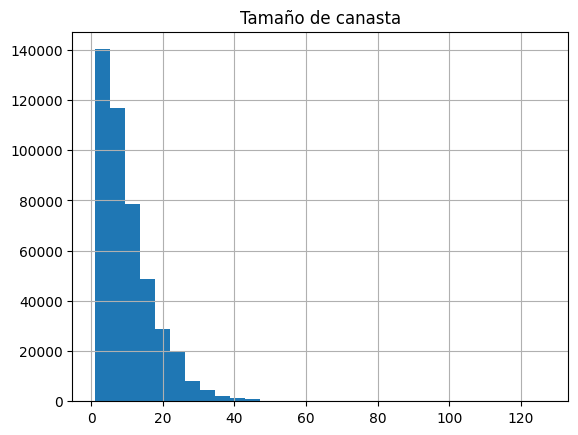

In [96]:
basket_size = obt.groupby('order_id')['product_id'].count()

basket_size.hist(bins=30)
plt.title('Tamaño de canasta')
plt.show()

In [97]:
product_reorder = obt.groupby('product_name')['reordered'].mean()
product_reorder.sort_values(ascending=False).head(20)

product_name
Palmiers- Petite                                                              1.0
Old Fashioned Red Liquorice                                                   1.0
Pain Relieving Cleansing Spray                                                1.0
Bresaola                                                                      1.0
English Cucumber                                                              1.0
VitaSea Juice                                                                 1.0
King Size Chocolate Candy With Peanuts                                        1.0
Kombucha Blueberry Basil                                                      1.0
Kids Strawberry Banana Low-Fat Yogurt 25% Less Sugar                          1.0
Sriracha Cashews                                                              1.0
Squirt Rub R 12 Floz 12 Pk 144 Floz                                           1.0
Squirt 'N Mop Multi-Surface Floor Cleaner- Original                           1.0
Old

In [98]:
user_reorder = obt.groupby('user_id')['reordered'].mean()
user_reorder.describe()

count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: reordered, dtype: float64

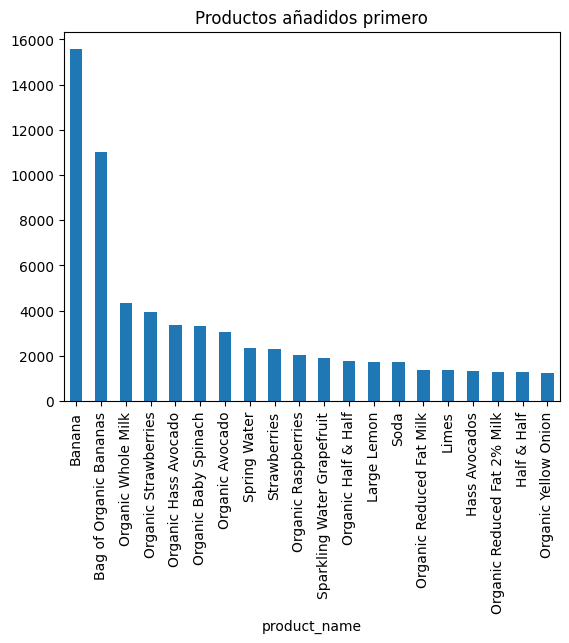

In [99]:
first_products = obt[obt['add_to_cart_order'] == 1]['product_name'].value_counts().head(20)

first_products.plot(kind='bar')
plt.title('Productos añadidos primero')
plt.show()

**C2. ¿Son los primeros productos un síntoma de fidelidad? (Spearman o Pearson):**
Para los 20 objetos que con mayor frecuencia las personas agregan como posición #1 al carrito, elabora una lógica que calcule una matriz de correlación (en variables generadas o agrupadas) o genera gráficos de dispersión (Scatterplot). Compara si, a nivel de producto, ser posicionado primero tiene relación lineal con ser un producto de constante recompra global (el campo 'reordered').

In [100]:
# Top 20 productos que más veces aparecen en la posición 1 del carrito
top20_first = (
    obt[obt['add_to_cart_order'] == 1]['product_name']
    .value_counts()
    .head(20)
)

top20_first

product_name
Banana                         15562
Bag of Organic Bananas         11026
Organic Whole Milk              4363
Organic Strawberries            3946
Organic Hass Avocado            3390
Organic Baby Spinach            3336
Organic Avocado                 3044
Spring Water                    2336
Strawberries                    2308
Organic Raspberries             2024
Sparkling Water Grapefruit      1914
Organic Half & Half             1797
Large Lemon                     1737
Soda                            1733
Organic Reduced Fat Milk        1397
Limes                           1370
Hass Avocados                   1340
Organic Reduced Fat 2% Milk     1310
Half & Half                     1309
Organic Yellow Onion            1246
Name: count, dtype: int64

In [102]:
# Crear tabla resumen para esos 20 productos
top20_names = top20_first.index

c2_df = (
    obt[obt['product_name'].isin(top20_names)]
    .groupby('product_name')
    .agg(
        times_first=('add_to_cart_order', lambda x: (x == 1).sum()),
        total_times_ordered=('product_id', 'count'),
        reorder_rate=('reordered', 'mean')
    )
    .reset_index()
)

# ordenar por frecuencia como primer producto
c2_df = c2_df.sort_values(by='times_first', ascending=False)

c2_df

,product_name,times_first,total_times_ordered,reorder_rate
1,Banana,15562,66050,0.844254
0,Bag of Organic Bananas,11026,53297,0.834006
14,Organic Whole Milk,4363,19600,0.829133
13,Organic Strawberries,3946,37039,0.773212
9,Organic Hass Avocado,3390,29773,0.793639
7,Organic Baby Spinach,3336,33971,0.772217
6,Organic Avocado,3044,24689,0.759164
18,Spring Water,2336,7675,0.810814
19,Strawberries,2308,20018,0.696623
10,Organic Raspberries,2024,19197,0.768245


In [103]:
# Correlaciones
pearson_corr = c2_df['times_first'].corr(c2_df['reorder_rate'], method='pearson')
spearman_corr = c2_df['times_first'].corr(c2_df['reorder_rate'], method='spearman')

print("Correlación de Pearson:", pearson_corr)
print("Correlación de Spearman:", spearman_corr)

Correlación de Pearson: 0.515684187972957
Correlación de Spearman: 0.4812030075187969


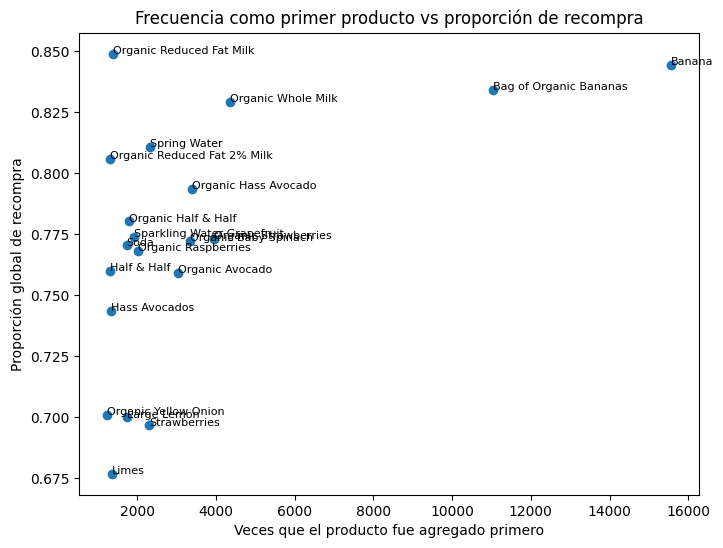

In [104]:
# Scatterplot
plt.figure(figsize=(8,6))
plt.scatter(c2_df['times_first'], c2_df['reorder_rate'])

for _, row in c2_df.iterrows():
    plt.text(row['times_first'], row['reorder_rate'], row['product_name'], fontsize=8)

plt.title('Frecuencia como primer producto vs proporción de recompra')
plt.xlabel('Veces que el producto fue agregado primero')
plt.ylabel('Proporción global de recompra')
plt.show()

In [105]:
c2_df[['times_first', 'total_times_ordered', 'reorder_rate']].corr(method='pearson')

,times_first,total_times_ordered,reorder_rate
times_first,1.000000,0.896869,0.515684
total_times_ordered,0.896869,1.000000,0.264281
reorder_rate,0.515684,0.264281,1.000000


In [106]:
c2_df[['times_first', 'total_times_ordered', 'reorder_rate']].corr(method='spearman')

,times_first,total_times_ordered,reorder_rate
times_first,1.000000,0.739850,0.481203
total_times_ordered,0.739850,1.000000,-0.007519
reorder_rate,0.481203,-0.007519,1.000000


El análisis de correlación muestra que existe una relación positiva moderada entre la frecuencia con la que un producto es agregado en la primera posición del carrito (times_first) y su proporción de recompra (reorder_rate), con valores de 0.51 (Pearson) y 0.48 (Spearman). Esto indica que los productos que los usuarios priorizan al inicio del proceso de compra tienden a ser también productos recurrentes, lo que sugiere un comportamiento de fidelidad asociado a la memoria o hábito de consumo.

Sin embargo, la relación no es perfecta, lo que indica que la posición en el carrito no es el único factor determinante de la recompra. Adicionalmente, se observa que la cantidad total de veces que un producto es comprado (total_times_ordered) no presenta una relación significativa con la proporción de recompra, lo que sugiere que popularidad y fidelidad no son necesariamente equivalentes.

En términos de negocio, estos resultados indican que los productos agregados primero al carrito pueden ser buenos candidatos para estrategias de fidelización, promociones recurrentes o posicionamiento destacado en la interfaz de compra.

**C3. Para cada producto, ¿cual es la proporcion de re-compras?**

In [107]:
product_reorder = obt.groupby('product_name')['reordered'].mean()
product_reorder.sort_values(ascending=False).head(20)

product_name
Palmiers- Petite                                                              1.0
Old Fashioned Red Liquorice                                                   1.0
Pain Relieving Cleansing Spray                                                1.0
Bresaola                                                                      1.0
English Cucumber                                                              1.0
VitaSea Juice                                                                 1.0
King Size Chocolate Candy With Peanuts                                        1.0
Kombucha Blueberry Basil                                                      1.0
Kids Strawberry Banana Low-Fat Yogurt 25% Less Sugar                          1.0
Sriracha Cashews                                                              1.0
Squirt Rub R 12 Floz 12 Pk 144 Floz                                           1.0
Squirt 'N Mop Multi-Surface Floor Cleaner- Original                           1.0
Old

**C4. Para cada usuario, ¿cual es la proporcion de re-compras de los productos comprados?**

In [108]:
user_reorder = obt.groupby('user_id')['reordered'].mean()
user_reorder.describe()

count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: reordered, dtype: float64

**C5. ¿Cuales son los top 20 productos que los clientes ponen primero en sus carritos?**

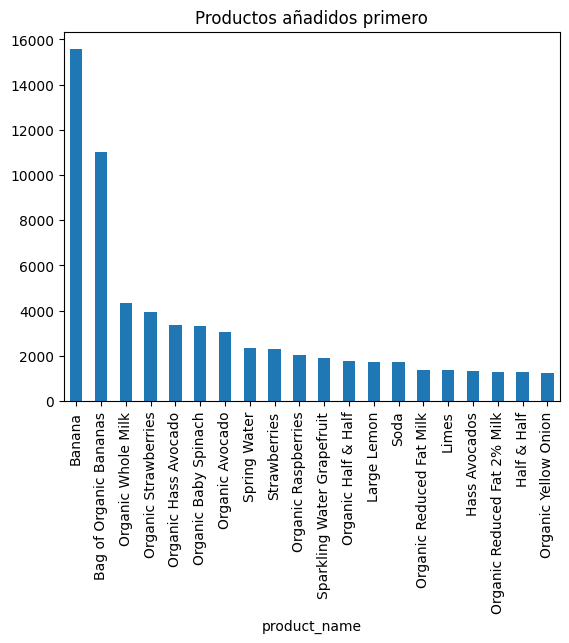

In [109]:
first_products = obt[obt['add_to_cart_order'] == 1]['product_name'].value_counts().head(20)

first_products.plot(kind='bar')
plt.title('Productos añadidos primero')
plt.show()

### Tus conclusiones avanzadas [Grupo C]:
(Enuncia las posibles relaciones matemáticas encontradas o variables dispersas)

El análisis multivariado permitió identificar relaciones relevantes entre variables clave del comportamiento de compra. En primer lugar, el tamaño de la canasta presenta una distribución sesgada, donde la mayoría de los pedidos contiene pocos productos, mientras que existe una cola larga de órdenes con un número elevado de artículos, lo que sugiere comportamientos de compra ocasionalmente intensivos.

A nivel de producto, se evidenció que la proporción de recompra varía significativamente, lo que indica que ciertos productos presentan altos niveles de fidelidad, mientras que otros responden más a compras ocasionales. El análisis de los productos agregados en primera posición muestra que estos corresponden principalmente a bienes de consumo frecuente, como frutas, lácteos y productos básicos, lo cual sugiere una priorización cognitiva por parte del usuario.

En cuanto a la relación entre la posición en el carrito y la fidelidad, se encontró una correlación positiva moderada entre la frecuencia con la que un producto es agregado primero (times_first) y su proporción de recompra (reorder_rate), con valores de aproximadamente 0.51 (Pearson) y 0.48 (Spearman). Esto indica que, aunque no existe una relación lineal perfecta, los productos que se agregan primero tienden a ser más recurrentes, lo que sugiere un vínculo entre prioridad de selección y hábito de consumo.

Sin embargo, también se observó que la cantidad total de veces que un producto es comprado no presenta una relación fuerte con su tasa de recompra, lo que indica que popularidad y fidelidad no son necesariamente equivalentes. En conjunto, estos resultados evidencian que el comportamiento de compra está influenciado por múltiples factores, y que las variables analizadas presentan tanto relaciones moderadas como dispersiones significativas.

# Conclusión General Ejecutiva
Resume en un párrafo las principales fortalezas, falencias detectadas en la gobernanza inicial de este dataset, y los descubrimientos de negocio clave que proporcionarías a la directiva de Instacart.

El análisis integral del dataset evidencia que, si bien la estructura relacional de los datos es sólida y permite una integración eficiente para análisis, existen falencias en la gobernanza inicial, especialmente en las dimensiones de completitud y precisión, reflejadas en la presencia de valores ausentes, duplicados y algunas inconsistencias en tipos de datos. Estas situaciones requirieron procesos de limpieza y validación para garantizar la confiabilidad del análisis.

Desde el punto de vista de negocio, se identificaron patrones claros de comportamiento del consumidor. La demanda presenta concentraciones en horarios específicos del día y variaciones según el día de la semana, lo que sugiere oportunidades para optimizar la logística y la disponibilidad de productos. Se observó que la frecuencia de compra presenta una distribución heterogénea, con usuarios altamente recurrentes y otros de baja actividad, lo que permite segmentar estrategias de retención.

En términos de productos, se evidenció una fuerte concentración de la demanda en un grupo reducido de artículos (principio de Pareto), así como diferencias significativas en las tasas de recompra, lo que permite identificar productos clave para estrategias de fidelización. Adicionalmente, se encontró que los productos que los usuarios agregan primero al carrito tienden a estar asociados a hábitos de consumo recurrente, aunque esta relación no es determinante.

En conjunto, estos hallazgos permiten inferir oportunidades estratégicas para Instacart, tales como la optimización del surtido, la personalización de recomendaciones y el diseño de campañas enfocadas en productos de alta fidelidad y usuarios recurrentes, con el objetivo de maximizar la retención y el valor del cliente.